# Bevölkerungdichte nach unterschiedlichen räumlichen Ausprägungen, seit 2009 

Bevölkerungdichte nach unterschiedlichen räumlichen Ausprägungen, seit 2009


Datum: 08.05.2024

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_bevoelkerungsdichten_od5802

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_bevoelkerungsdichten_od5802

### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [3]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [4]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [8]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [9]:
package_name = "bev_bestand_jahr_bevoelkerungsdichten_od5802"

In [10]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV580OD5802"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_bevoelkerungsdichten_od5802/download/BEV580OD5802.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_bevoelkerungsdichten_od5802 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_bevoelkerungsdichten_od5802 

data_source: web


In [11]:
data2betested.head(2).T

,0,1
RaumKategorie,Gesamte Stadt,Gesamte Stadt
RaumSort,0,0
RaumLang,Ganze Stadt,Ganze Stadt
StichtagDatJahr,2009-01-01 00:00:00,2010-01-01 00:00:00
AnzBestWir,382906,385468
DichteT,42,42
DichteL,59,59
DichteS,102,103


Berechne weitere Attribute falls notwendig

In [12]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

RaumKategorie                  object
RaumSort                        int64
RaumLang                       object
StichtagDatJahr        datetime64[ns]
AnzBestWir                      int64
DichteT                       float64
DichteL                       float64
DichteS                       float64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [13]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 2009 und ein Maximumjahr von 2024


In [14]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2009-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [15]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 751 to 0
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   RaumKategorie        752 non-null    object        
 1   RaumSort             752 non-null    int64         
 2   RaumLang             752 non-null    object        
 3   StichtagDatJahr      752 non-null    datetime64[ns]
 4   AnzBestWir           752 non-null    int64         
 5   DichteT              752 non-null    float64       
 6   DichteL              752 non-null    float64       
 7   DichteS              752 non-null    float64       
 8   StichtagDatJahr_str  752 non-null    object        
 9   Jahr                 752 non-null    datetime64[ns]
 10  Jahr_end             752 non-null    datetime64[ns]
 11  Jahr_nbr             752 non-null    int32         
dtypes: datetime64[ns](3), float64(3), int32(1), int64(2), object(3)
memory usage: 204.7 KB


In [16]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 752 rows (observations) and 12 columns (variables).
There seem to be 0 exact duplicates in the data.


Welches sind die Quartiere ohne Werte bei BEW?

In [17]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,RaumKategorie,RaumSort,RaumLang,StichtagDatJahr,AnzBestWir,DichteT,DichteL,DichteS,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()
#data2betested = data2betested.reset_index()

In [19]:
data2betested.index.year.unique()

Index([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024],
      dtype='int32', name='Jahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,RaumKategorie,RaumLang,StichtagDatJahr,StichtagDatJahr_str,Jahr_end
count,752,752,752,752,752
unique,3,47,NaN,16,NaN
top,Stadtquartier,Ganze Stadt,NaN,2009-01-01,NaN
freq,544,16,NaN,47,NaN
mean,NaN,NaN,2016-07-02 00:00:00,NaN,2017-07-01 06:00:00
min,NaN,NaN,2009-01-01 00:00:00,NaN,2009-12-31 00:00:00
25%,NaN,NaN,2012-10-01 12:00:00,NaN,2013-09-30 18:00:00
50%,NaN,NaN,2016-07-02 00:00:00,NaN,2017-07-01 12:00:00
75%,NaN,NaN,2020-04-01 12:00:00,NaN,2021-04-01 06:00:00
max,NaN,NaN,2024-01-01 00:00:00,NaN,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,RaumSort,AnzBestWir,DichteT,DichteL,DichteS,Jahr_nbr
count,752,752,752,752,752,752
mean,63,"26,640",55,70,116,"2,016"
std,36,"59,639",33,31,48,5
min,0,634,11,14,23,"2,009"
25%,31,"7,370",31,46,85,"2,013"
50%,63,"13,026",44,66,109,"2,016"
75%,92,"26,086",78,87,135,"2,020"
max,123,"448,664",154,164,252,"2,024"


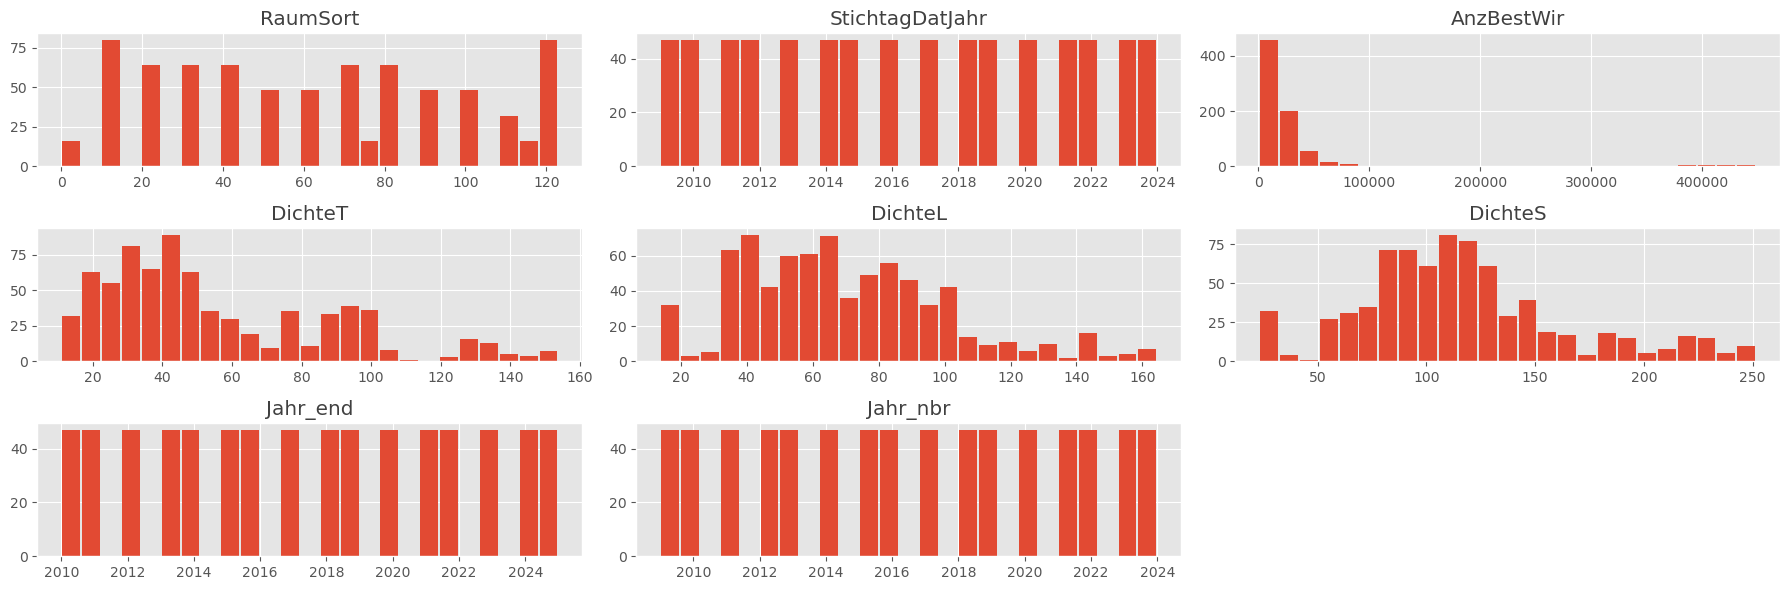

In [22]:
# plot a histogram for each numerical feature
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,RaumKategorie,RaumSort,RaumLang,StichtagDatJahr,AnzBestWir,DichteT,DichteL,DichteS,StichtagDatJahr_str,Jahr_end,Jahr_nbr
Jahr,,,,,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

RaumKategorie          0
RaumSort               0
RaumLang               0
StichtagDatJahr        0
AnzBestWir             0
DichteT                0
DichteL                0
DichteS                0
StichtagDatJahr_str    0
Jahr_end               0
Jahr_nbr               0
dtype: int64

### Gruppierungen

In [25]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,sum_AnzBestWir
0,2024-01-01,1345992
1,2023-01-01,1341246
2,2022-01-01,1329111


In [26]:
data2betested.columns

Index(['RaumKategorie', 'RaumSort', 'RaumLang', 'StichtagDatJahr', 'AnzBestWir', 'DichteT',
       'DichteL', 'DichteS', 'StichtagDatJahr_str', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [27]:
agg_Raum = data2betested.loc[data_max_jahr]\
    .groupby(['RaumKategorie', 'RaumSort', 'RaumLang','DichteT','DichteL', 'DichteS']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum'), meanDichteT=('DichteT', 'mean')) \
    .sort_values('RaumSort', ascending=True) 
agg_Raum.reset_index().head(10)

,RaumKategorie,RaumSort,RaumLang,DichteT,DichteL,DichteS,sum_AnzBestWir,meanDichteT
0,Gesamte Stadt,0,Ganze Stadt,49,69,118,448664,49
1,Stadtkreis,10,Kreis 1,32,37,66,5769,32
2,Stadtquartier,11,Rathaus,91,119,182,3260,91
3,Stadtquartier,12,Hochschulen,12,15,27,684,12
4,Stadtquartier,13,Lindenhof,39,39,80,1040,39
5,Stadtquartier,14,City,13,14,26,785,13
6,Stadtkreis,20,Kreis 2,35,57,107,38247,35
7,Stadtquartier,21,Wollishofen,38,63,111,21800,38
8,Stadtquartier,23,Leimbach,22,41,111,6415,22
9,Stadtquartier,24,Enge,42,58,99,10032,42


### Pivotiere

In [28]:
data2betested.reset_index().columns

Index(['Jahr', 'RaumKategorie', 'RaumSort', 'RaumLang', 'StichtagDatJahr', 'AnzBestWir', 'DichteT',
       'DichteL', 'DichteS', 'StichtagDatJahr_str', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [29]:
pivoted_df = data2betested.pivot_table(
    index='Jahr_nbr',
    columns= ('RaumKategorie'),
    values=['DichteT','DichteL', 'DichteS'],
    aggfunc='median'
)

# Sortieren nach der Aggregation 
#pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df = pivoted_df.sort_index(ascending=False)

# Anzeigen des Ergebnisses
print(pivoted_df.head(8).T)

Jahr_nbr               2024  2023  2022  2021  2020  2019  2018  2017
        RaumKategorie                                                
DichteL Gesamte Stadt    69    69    68    67    67    67    66    65
        Stadtkreis       70    69    69    67    67    67    66    65
        Stadtquartier    71    72    71    70    71    71    70    70
DichteS Gesamte Stadt   118   118   117   115   114   114   112   111
        Stadtkreis      119   120   119   118   118   118   116   116
        Stadtquartier   119   118   116   114   112   112   112   112
DichteT Gesamte Stadt    49    49    48    48    47    47    47    46
        Stadtkreis       52    53    52    51    51    51    50    50
        Stadtquartier    47    47    46    45    45    45    44    44


### Visualisierungen nach Zeitausschnitten

In [30]:
data2betested

,RaumKategorie,RaumSort,RaumLang,StichtagDatJahr,AnzBestWir,DichteT,DichteL,DichteS,StichtagDatJahr_str,Jahr_end,Jahr_nbr
Jahr,,,,,,,,,,,
2009-01-01,Gesamte Stadt,0,Ganze Stadt,2009-01-01,382906,42,59,102,2009-01-01,2009-12-31,2009
2009-01-01,Stadtkreis,20,Kreis 2,2009-01-01,29809,27,44,82,2009-01-01,2009-12-31,2009
2009-01-01,Stadtquartier,91,Albisrieden,2009-01-01,17675,38,65,100,2009-01-01,2009-12-31,2009
2009-01-01,Stadtkreis,80,Kreis 8,2009-01-01,15212,32,53,85,2009-01-01,2009-12-31,2009
2009-01-01,Stadtquartier,34,Sihlfeld,2009-01-01,20464,125,126,214,2009-01-01,2009-12-31,2009
...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01,Stadtquartier,44,Hard,2024-01-01,13154,94,94,166,2024-01-01,2024-12-31,2024
2024-01-01,Stadtquartier,101,Höngg,2024-01-01,24810,36,54,100,2024-01-01,2024-12-31,2024
2024-01-01,Stadtquartier,71,Fluntern,2024-01-01,8787,31,41,62,2024-01-01,2024-12-31,2024


In [31]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('RaumKategorie == "Stadtkreis"')
    ,x = 'StichtagDatJahr:T'
    ,y = 'AnzBestWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fläche in ha'
    ,category = "RaumLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Bevölkerung nach Stadtkreis, "+data_min_jahr + "-"+data_max_jahr
)
#grafik1

In [32]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('RaumKategorie == "Stadtkreis"')
    ,x = 'StichtagDatJahr:T'
    ,y = 'DichteT:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fläche in ha'
    ,category = "RaumLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Bevölkerungsdichte (Totalfläche) nach Stadtkreis, "+data_min_jahr + "-"+data_max_jahr
)
#grafik2

In [33]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('RaumKategorie == "Stadtkreis"')
    ,x = 'StichtagDatJahr:T'
    ,y = 'DichteS:Q' #DichteS
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fläche in ha'
    ,category = "RaumLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Bevölkerungsdichte (Siedlungsfläche) nach Stadtkreis, "+data_min_jahr + "-"+data_max_jahr
)
#grafik3

##### Kombinierte Grafik in Altair

In [34]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik2)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2, grafik3, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [35]:
data2betested.columns

Index(['RaumKategorie', 'RaumSort', 'RaumLang', 'StichtagDatJahr', 'AnzBestWir', 'DichteT',
       'DichteL', 'DichteS', 'StichtagDatJahr_str', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

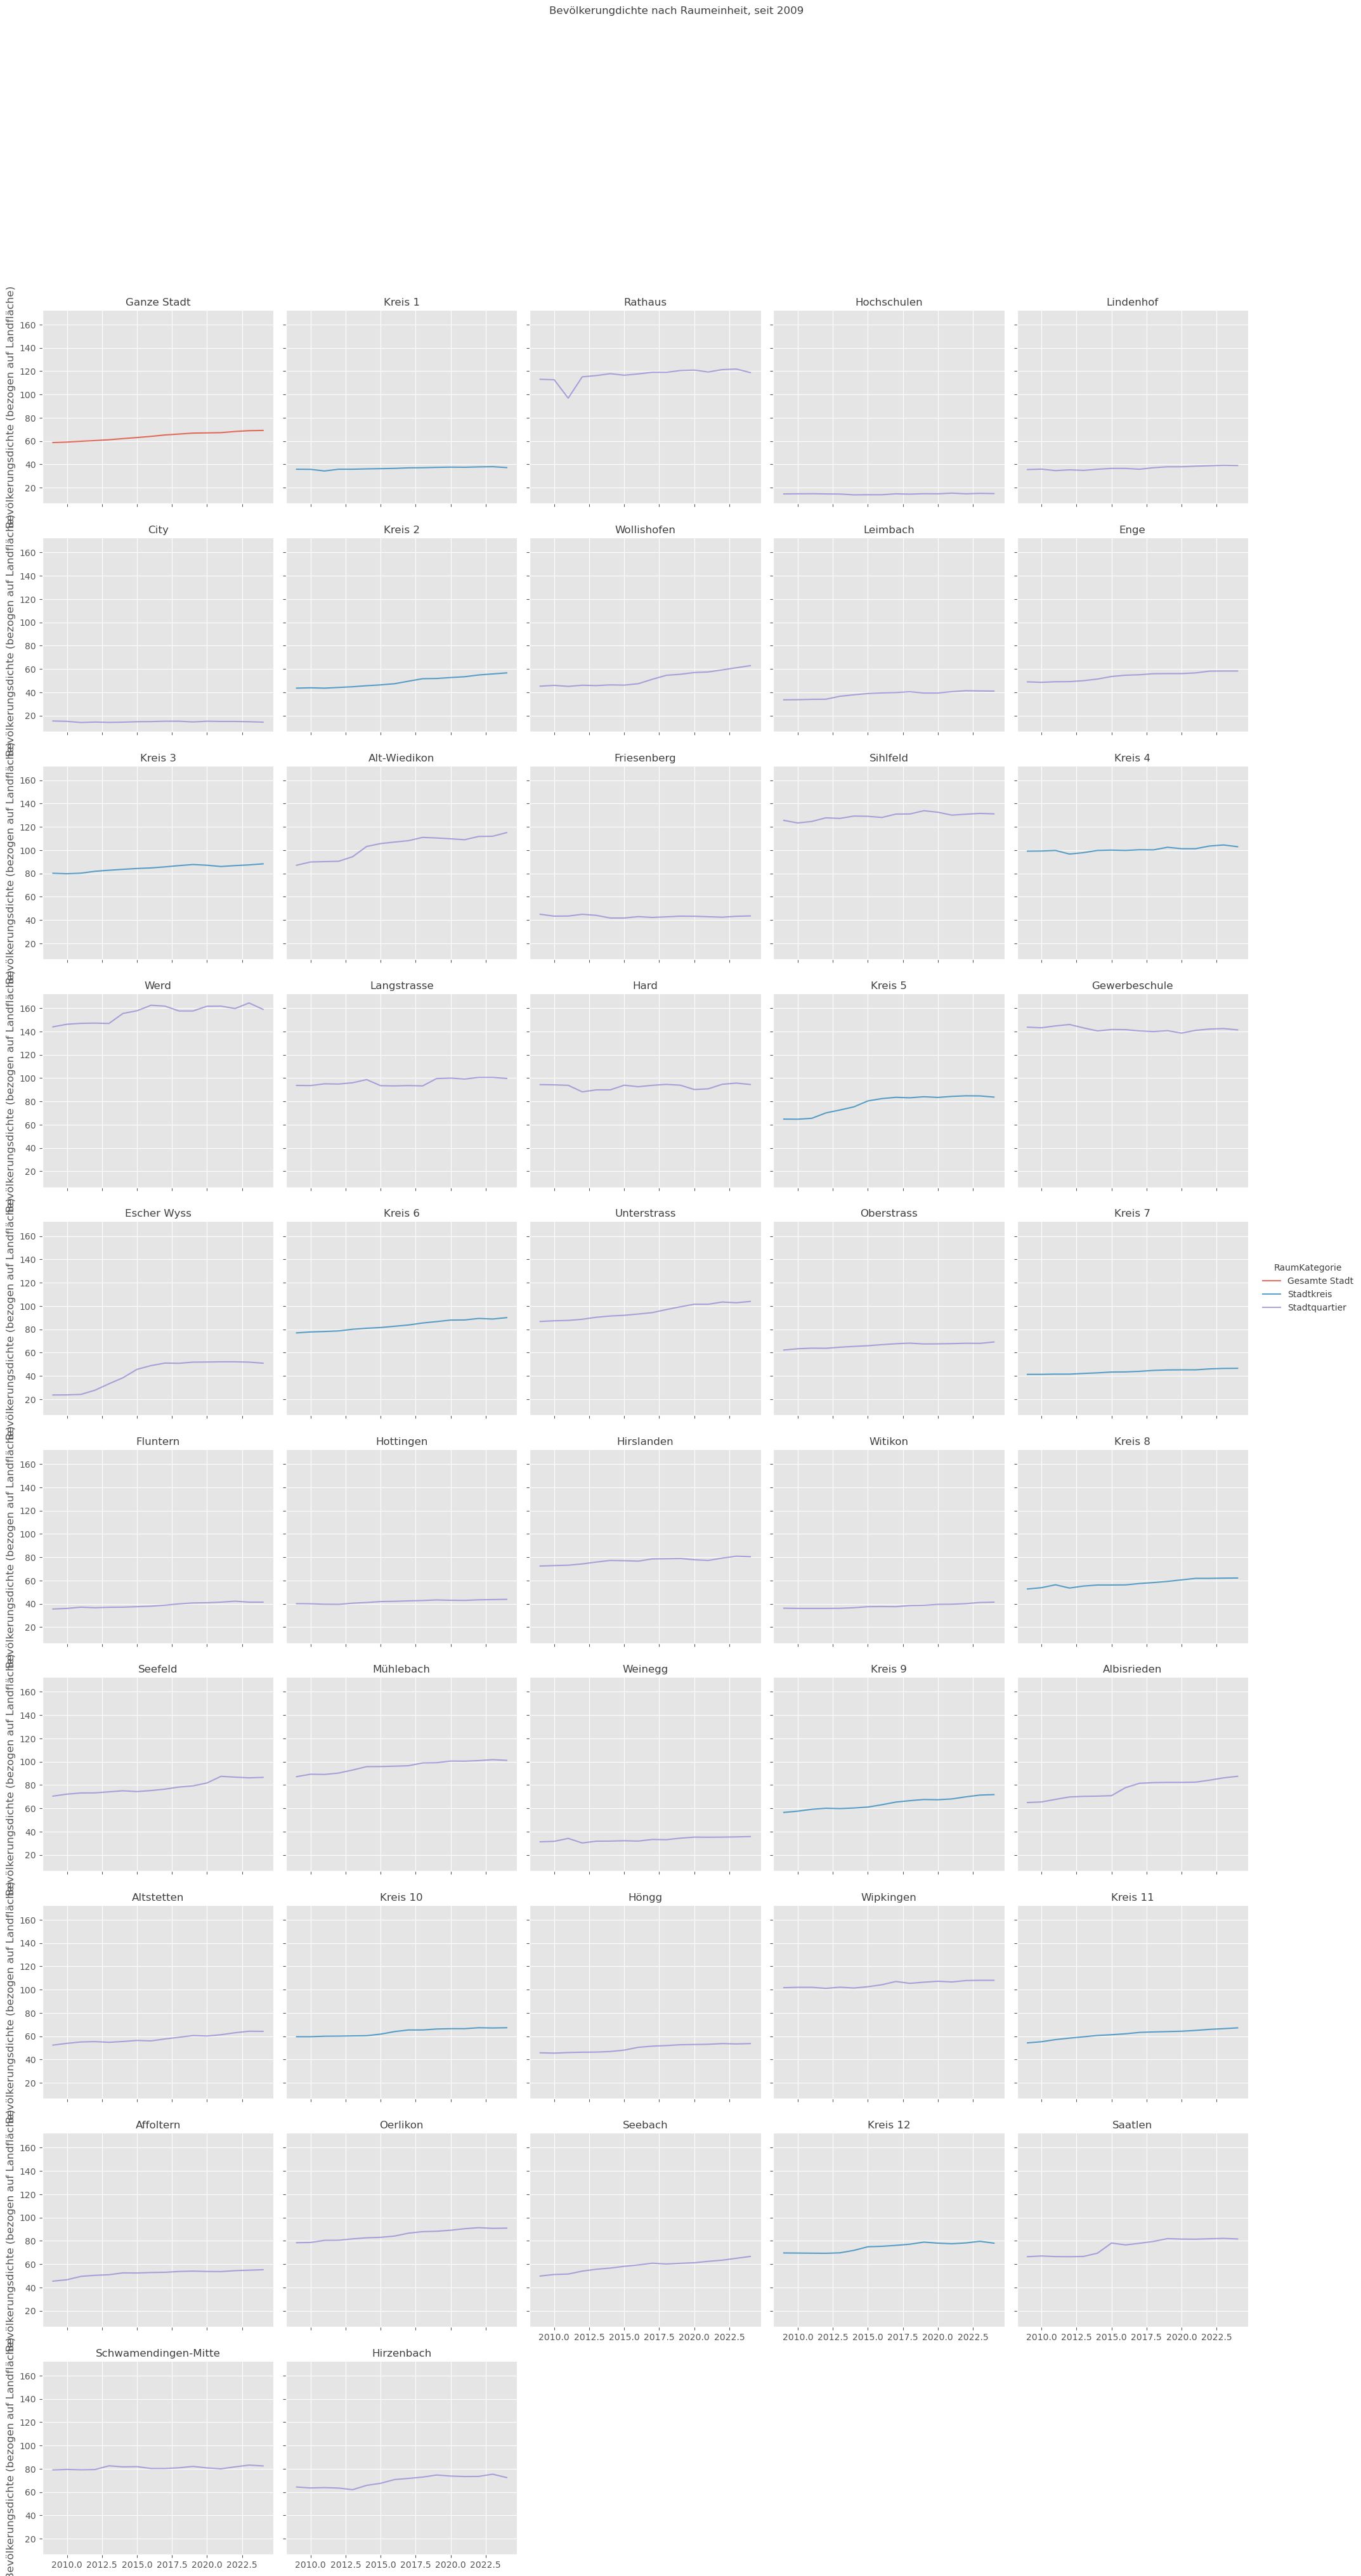

In [36]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('RaumSort', ascending=True)
    ,col = "RaumLang"
    ,hue = "RaumKategorie"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_nbr"
    ,y = "DichteL"
    ,ylabel= "Bevölkerungsdichte (bezogen auf Landfläche)"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerungdichte nach Raumeinheit, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

**Sharepoint Status anpassen!**

Record auf Sharepoint in Bearbeitungsmodus öffnen: **[Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=831&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**